In [45]:
from matplotlib import pyplot as plt
from scipy.constants import Boltzmann as kB
from scipy.constants import elementary_charge as q
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LinearSegmentedColormap, to_rgba

import numpy as np

k_b_ev = kB/q       # Boltzmann constant in eV/K

In [46]:
# Expresión de la velocidad mínima

size = 10e-9                    # Tamaño del dispositivo en metros
temperature = 300               # Temperatura en Kelvin
potencial = 6                   # Potencial en Voltios
E_field = potencial / size

# Constantes de la expresión
Vector_gamma_drift = np.linspace(5, 11, 6)
Vector_E_m = np.linspace(0.8, 1.2, 41)
t_0 = 1e13
cte_red = 0.25e-9

In [47]:
oxigen_velocity = np.zeros((len(Vector_gamma_drift), len(Vector_E_m)))
i = 0

# Calculo la velocidad en cada caso con esas constantes
for gamma_drift in Vector_gamma_drift:
    j = 0
    for E_m in Vector_E_m:
        senoh = np.sinh((cte_red * E_field * gamma_drift)/(2 * k_b_ev * temperature))
        exp_velocity = np.exp(-E_m / (k_b_ev * temperature))
        oxigen_velocity[i][j] = 2 * t_0 * cte_red * (senoh * exp_velocity)

        # Incremento el contador para el siguiente E_m
        j = j + 1

    # Incremento el contador para el siguiente gamma_drift
    i = i + 1

# Lo paso a nm/s
oxigen_velocity = oxigen_velocity * 1e9
oxigen_velocity = np.transpose(oxigen_velocity)

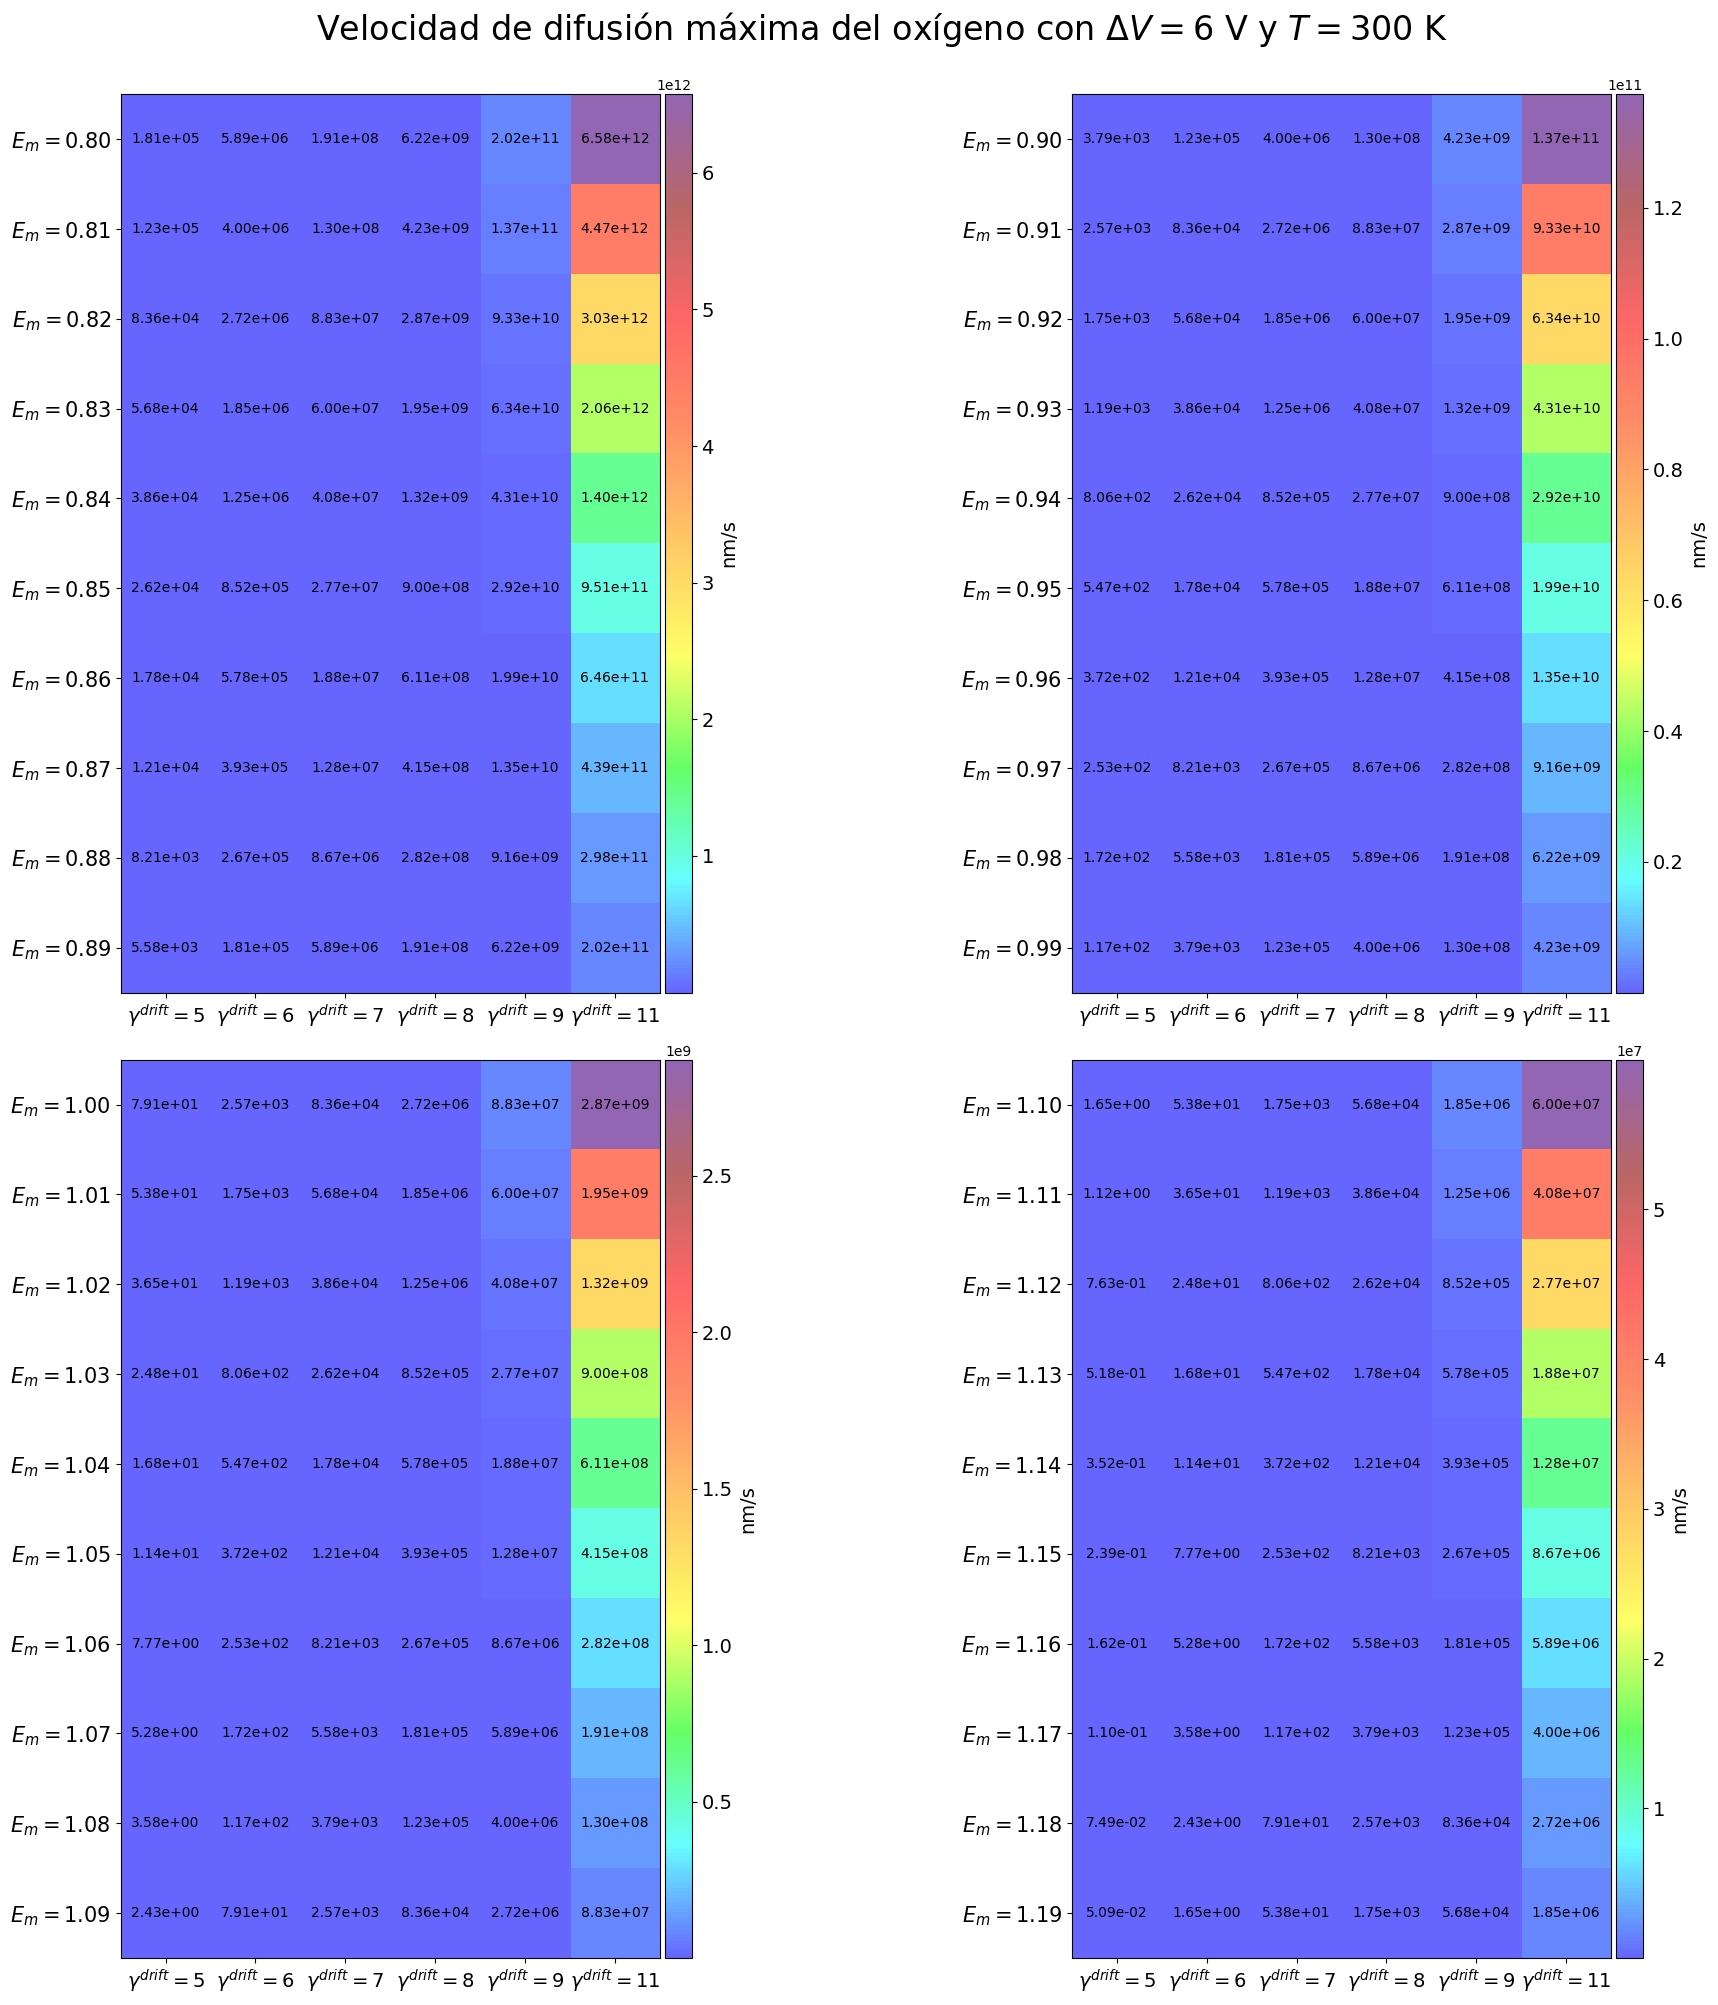

In [48]:
# Función para mezclar un color con blanco
def lighten_color(color, amount=0.5):
    try:
        c = np.array(to_rgba(color))
        white = np.array([1, 1, 1, 1])
        return (1 - amount) * c + amount * white
    except ValueError:
        return color


# Definir los colores originales
colores = ['#0000FF', '#00FFFF', '#00FF00', '#FFFF00', '#FFA500', '#FF4500', '#FF0000', '#8B0000', '#4B0082']

# Definir los colores que deseas usar en la barra de color
colores = [lighten_color(color, 0.40) for color in colores]

# Crear un mapa de colores personalizado
custom_cmap = LinearSegmentedColormap.from_list('custom_cmap', colores)

fig, axs = plt.subplots(2, 2, figsize=(20, 20))

inicio = 0
final = 10

for ax in axs.flat:

    oxigen_velocity_sub = oxigen_velocity[inicio:final, :]
    Vector_E_m_sub = Vector_E_m[inicio:final]

    im = ax.imshow(oxigen_velocity_sub, cmap=custom_cmap)

    # Añadir los valores en cada casilla
    for (i, j), val in np.ndenumerate(oxigen_velocity_sub):
        ax.text(j, i, f'{val:.2e}', ha='center', va='center', fontsize=10, color='black')

    # Crear un eje para la barra de color que tenga el mismo tamaño que el plot
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = plt.colorbar(im, cax=cax)

    # Añadir la etiqueta a la barra de color
    cbar.set_label('nm/s', fontsize=14)

    # Aumentar el tamaño de los números en la barra de color
    cbar.ax.tick_params(labelsize=14)  # Ajusta el valor según tus necesidades

    # Valor de la velocidad mínima para que se pueda mover una casilla
    v_min_1 = 127.5
    v_min_2 = 42.5
    v_min_3 = 25.5

    v_min = [v_min_1, v_min_2, v_min_3, 0.001, 0.003, 0.005]

    for i in [0, 1, 2]:

        v_minima = v_min[i]
        delta_t = v_min[i+3]

        # Normalizar el valor con respecto a los límites de la barra de color
        norm = plt.Normalize(vmin=oxigen_velocity_sub.min(), vmax=oxigen_velocity_sub.max())
        valor_normalizado = norm(v_minima)

        # print("Valor mínimo: ", v_minima)
        # print("Valor normalizado: ", valor_normalizado)

        if valor_normalizado > 0.005 and valor_normalizado < 0.995:
            # Dibujar la línea en la barra de color
            cbar.ax.axhline(y=valor_normalizado * cbar.ax.get_ylim()[1],
                            color='black', linewidth=2)  # Ajustar la posición de la línea

            # Añadir la etiqueta en LaTeX al lado de la línea violeta
            cbar.ax.text(1.5, valor_normalizado * cbar.ax.get_ylim()[1],
                         rf'$v_m = {v_minima} \, \mathrm{{nm/s}}$ ($\Delta t = {delta_t}$ s)',
                         color='black', fontsize=12, va='center')
            print("Añadida etiqueta")

    # Añadir etiquetas a los ejes
    columnas = [r'$\gamma^{{drift}} = ' + str(int(i)) + r'$' for i in Vector_gamma_drift]
    filas = [r'$E_m = {:.2f}$'.format(i) for i in Vector_E_m_sub]

    ax.set_yticks(np.arange(len(filas)))
    ax.set_yticklabels(filas, rotation=0, fontsize=15)
    ax.set_xticks(np.arange(len(columnas)))
    ax.set_xticklabels(columnas, rotation=0, fontsize=14)

    inicio = inicio + 10
    final = final + 10

# Añadir un título al conjunto de los plots
fig.suptitle(
    f'Velocidad de difusión máxima del oxígeno con $\Delta V = {potencial}$ V y $T = {temperature}$ K', fontsize=24, y=1)

# Ajustar el layout para que no se solapen los subplots
plt.tight_layout()

# Guardar la figura en formato PDF
plt.savefig('figura.pdf', format='pdf')

# Mostrar la figura con los 4 subplots
plt.show()